In [2]:
%load_ext autoreload
%autoreload 2
import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [3]:
from torchcfm.conditional_flow_matching import *
from torchdyn.core import NeuralODE
from torchcfm.utils import plot_trajectories, torch_wrapper

In [4]:
from torchdiffeq import odeint
from torchcfm.optimal_transport import wasserstein

In [5]:
import matplotlib.pyplot as plt
from matplotlib import cm

In [6]:
device = 'cuda:3'

In [7]:
adata = sc.read_h5ad(f"data/klein_subset.h5ad")
cellstate_key = "DM_EigenVectors_multiscaled"
n_dimension = 5
base_cellstate = adata.obsm[cellstate_key][:,:n_dimension].copy()

In [8]:
coords = adata.obsm[cellstate_key]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm[f"{cellstate_key}_standardized"] = coords

In [9]:
cellstate_key = "DM_EigenVectors_multiscaled"
timepoint_key = 'timepoint_tx_days'

In [10]:
larry = sc.read_h5ad("data/Weinreb2020_fate_prediction.h5ad")
adata = sc.read_h5ad("data/klein_subset.h5ad")
Fate_bias = pd.read_csv("data/Weinreb/F_obs.csv", index_col=0)
Fate_bias.index = Fate_bias.index.astype(str)

overlapped_cbs = np.intersect1d(Fate_bias.index, adata.obs_names)

Fate_bias = Fate_bias.loc[overlapped_cbs]

In [11]:
adata

AnnData object with n_obs × n_vars = 47907 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'Day2_u', 'Day4_u', 'Day6_u', 'palantir_pseudotime', 'palantir_entropy'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'Delta_DM', 'X_diffmap', 'X_pca', 'X_umap', 'palantir_fate_probabilities'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In [12]:
adata.obs['Annotation'].nunique()

11

In [13]:
X_t0 = adata[overlapped_cbs].obsm[cellstate_key].copy()

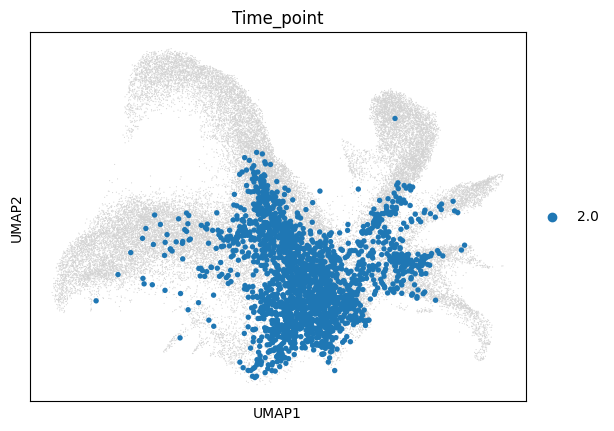

In [14]:
fig = sc.pl.umap(adata, show=False, return_fig=True)
sc.pl.umap(adata[overlapped_cbs], color='Time_point', ax=fig.gca())

In [15]:
import annoy

In [16]:
cellstate = adata.obsm[cellstate_key]
n_trees = 10
idx = annoy.AnnoyIndex(cellstate.shape[1], "euclidean")

[idx.add_item(i, cellstate[i]) for i in range(len(adata))]
idx.build(n_trees)

DM = torch.Tensor(adata[overlapped_cbs].obsm[cellstate_key].toarray())
print(DM.shape)

torch.Size([1989, 5])


In [17]:
def assign_celltype(X_t1, n_neighbors=20, cellstate='Annotation'):
    # nn = idx.get_nns_by_vector(X_t1, n_neighbors)
    # query_df = pd.DataFrame(adata[nn].obs['Annotation'].to_numpy().reshape(-1, n_neighbors)).T

    nn = np.array(
        [idx.get_nns_by_vector(X_t1[i], n_neighbors) for i in range(len(X_t1))]
    ).flatten()
    query_df = pd.DataFrame(adata[nn].obs[cellstate].to_numpy().reshape(-1, n_neighbors)).T
    return query_df

def compute_fate_bias(qeury_df, overlapped_cbs):
    dfs = []
    for i in range(len(overlapped_cbs)):
        series = pd.Categorical(
            qeury_df[i].values, categories=adata.obs['Annotation'].unique(), ordered=False
        )
        dfs.append(series.value_counts())

    df = pd.concat(dfs, axis=1)
    df.columns = overlapped_cbs
    df = df.T
    return df

In [18]:
import sklearn

def replace_undiff(F_hat):

    F_hat_filt = F_hat.copy().drop("undiff", axis=1)
    F_hat_filt_norm = F_hat_filt.div(F_hat_filt.sum(1), axis=0).fillna(0)

    # create a temp vector to add undiff label
    undiff = np.zeros(len(F_hat_filt_norm))
    replace_idx = np.where(F_hat_filt_norm.sum(1) == 0)
    #     print(f"{replace_idx[0].shape[0]} non-fates")
    undiff[replace_idx] = 1

    # add to normalized matrix
    F_hat_filt_norm["undiff"] = undiff
    F_hat_filt_norm.index = F_hat.index

    return F_hat_filt_norm

def compute_accuracy(F_obs, F_hat):
    y_true, y_pred = F_obs.idxmax(1).tolist(), F_hat.idxmax(1).tolist()
    return sklearn.metrics.accuracy_score(y_true, y_pred)

# PINN v

In [99]:
# ckpt_path = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=20-total_loss=0.21981135.ckpt"   # 0.38
ckpt_path = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=101-total_loss=0.32358119.ckpt"  # 0.4218200100553042
# ckpt_path = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_5/checkpoints/epoch=219-total_loss=0.11944110.ckpt"  # 0.04
 
# ckpt_path = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_6/checkpoints/epoch=20-total_loss=0.22227032.ckpt" # 0.38
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"PINN.models.{model_name}")

cellstate_key = ckpt_path.split("/")[1].split("-")[1].split("_n")[0]
n_timepoint = int(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])

# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

In [100]:
cellstate_key = ckpt_path.split("/")[1].split("-")[1].split("_n")[0]
n_timepoint = int(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])

In [101]:
def v_ode(t, state):
    s_in = state
    t_in = torch.full((s_in.shape[0],), t.item()).float().to(s_in.device)
    # dsdt
    return pde_model.v(s_in, t_in) 

In [102]:
t_list = adata.uns['pop']['t'] 
t_list = t_list / t_list[0]


s_in = torch.tensor(X_t0).to(device).float()

with torch.no_grad():
    s_t = odeint(v_ode, 
                y0 = s_in, 
                t = torch.linspace(1, 3, 2),
                atol = 1e-8,
                rtol = 1e-8,
                method = 'dopri5')
    traj = s_t.detach().cpu().numpy()

In [103]:
query_df_PINN = assign_celltype(traj[-1])
df_PINN = compute_fate_bias(query_df_PINN, overlapped_cbs)
compute_accuracy(Fate_bias, replace_undiff(df_PINN))

0.4218200100553042

# load TIGON model

In [37]:
# git clone TIGON 
sys.path.append('/ssd/users/Wergillius/Project/TIGON')
import utility

In [38]:
timepoints = [0.5, 1.0, 1.5]

In [39]:
ckpt = torch.load("logs/TIGON/model2/ckpt.pth")

In [40]:
LOSS = ckpt['LOSS']
Trans = ckpt['TRANS']
L2_1 = ckpt['L2_1']
L2_2 = ckpt['L2_2']
Sigma = ckpt['Sigma']

In [41]:
LOSS[80],LOSS[100]

(0.5170110464096069, 8.993673324584961)

In [42]:
best_checkpoint = torch.load("logs/TIGON/model2/ckpt_itr80.pth")
model_state_dict = best_checkpoint['func_state_dict']

In [43]:
device = 'cuda:3'

func = utility.UOT(in_out_dim=n_dimension, 
           hidden_dim=16, n_hiddens=4, activation='Tanh').to(device)
func.load_state_dict(model_state_dict)

v = func.hyper_net1.to(device)
g = func.hyper_net2.to(device)

In [55]:
with torch.no_grad():
    traj_0_1 = odeint(v,  y0 = s_in.to(device), 
              t = torch.linspace(0.5, 1.5, 2), method='dopri5'
              ).cpu()

In [57]:
query_df_TIGON = assign_celltype(traj_0_1[-1])
df_TIGON = compute_fate_bias(query_df_TIGON, overlapped_cbs)
compute_accuracy(Fate_bias, replace_undiff(df_TIGON))

0.1126194067370538

# OT_cfm model

In [59]:
savedir = "logs/CFM"
checkpoint = torch.load(f"{savedir}/Weinreb_{cellstate_key}_ot_cfm_.pt")
ot_cfm_model = checkpoint['model'].to(device)

In [60]:
node = NeuralODE(torch_wrapper(ot_cfm_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj_OTCFM = node.trajectory(
        s_in.to(device),
        t_span=torch.linspace(0, 2, 200),
    ).cpu()

query_df_OTCFM = assign_celltype(traj_OTCFM[-1])
df_OTCFM = compute_fate_bias(query_df_OTCFM, overlapped_cbs)
compute_accuracy(Fate_bias, replace_undiff(df_OTCFM))

0.42835595776772245

# SF2M

In [61]:
savedir = "logs/CFM"
checkpoint = torch.load(f"{savedir}/Weinreb_{cellstate_key}_sf2m_sigma_0.25.pt")
sf2m_model = checkpoint['model'].to(device)

In [62]:
node = NeuralODE(torch_wrapper(sf2m_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj_sf2m = node.trajectory(
        s_in.to(device),
        t_span=torch.linspace(0, 2, 200),
    ).cpu()

query_df_sf2m = assign_celltype(traj_sf2m[-1])
df_sf2m = compute_fate_bias(query_df_sf2m, overlapped_cbs)
compute_accuracy(Fate_bias, replace_undiff(df_sf2m))

0.40623428858722976

# Prescient

In [24]:
traj_prescient = np.load("logs/PRESCIENT/GOBP_cellcycle_DM-softplus_4_64-1e-06/seed_2/Diffusion_map_simulated.npy")

In [27]:
traj_prescient.shape

(1989, 5)

In [28]:
query_df_prescient = assign_celltype(traj_prescient)
df_prescient = compute_fate_bias(query_df_prescient, overlapped_cbs)
compute_accuracy(Fate_bias, replace_undiff(df_prescient))

0.31975867269984914

# TrajectoryNet

In [30]:
save = "logs/TrajectoryNet/DM_multiscaled_with_growth"
trajectory_TJN = np.load(f"{save}/fate_bias_trajectories_1d0-3d5.npy")
print(trajectory_TJN.shape)

(6, 1989, 5)


In [32]:
query_df_TJN = assign_celltype(trajectory_TJN[-1])
df_TJN = compute_fate_bias(query_df_TJN, overlapped_cbs)
compute_accuracy(Fate_bias, replace_undiff(df_TJN))

0.007541478129713424

# MIO flow

In [ ]:
trajectories = np.load("results/MIOFlow/klein_subset_DM_EigenVectors_multiscaled/fate_bias_trajectory.npy")